In [3]:
# --- INSTALL NECESSARY LIBRARIES ---
# Run this once if the libraries are not installed in your environment
# !pip install torch torchvision numpy pandas scikit-learn xgboost matplotlib seaborn joblib imbalanced-learn

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import joblib

from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [10]:
# --- CONFIGURATION ---
DATA_ROOT = 'preprocessed_dataset/' 
TRAIN_DIR = os.path.join(DATA_ROOT, 'train_images')
VALID_DIR = os.path.join(DATA_ROOT, 'valid_images')
TEST_DIR = os.path.join(DATA_ROOT, 'test_images')
TRAIN_CSV = os.path.join(DATA_ROOT, 'train.csv')
VALID_CSV = os.path.join(DATA_ROOT, 'valid.csv')
TEST_CSV = os.path.join(DATA_ROOT, 'test.csv')

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
FEATURE_DIM = 2048 # Output dimension of ResNet's GAP layer
N_COMPONENTS = 128 # PCA target dimension (Tunable)
RANDOM_STATE = 42

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# --- HELPER FUNCTIONS ---

class FeatureDataset(Dataset):
    """Custom Dataset for loading images for feature extraction."""
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id_code'] + '.png'
        img_path = os.path.join(self.img_dir, img_id)
        
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['diagnosis']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def get_resnet_extractor():
    """Load pre-trained ResNet50 and modify it to output the feature vector."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model = nn.Sequential(*list(model.children())[:-1]) # Remove final 'fc' layer
    for param in model.parameters():
        param.requires_grad = False
    model.eval()
    return model.to(DEVICE)

def extract_features(dataloader, extractor):
    """Iterate over DataLoader and extract features and labels."""
    features = []
    labels = []
    
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Extracting Features"):
            inputs = inputs.to(DEVICE)
            feature_map = extractor(inputs)
            # Apply Global Average Pooling: (B, 2048, H, W) -> (B, 2048)
            feature_vector = feature_map.mean(dim=[2, 3]) 
            
            features.append(feature_vector.cpu().numpy())
            labels.append(targets.numpy())
            
    return np.concatenate(features), np.concatenate(labels)

Using Device: cuda:0


In [11]:
# --- Load DataFrames ---
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test = pd.read_csv(TEST_CSV)

df_train['diagnosis'] = df_train['diagnosis'].astype(int)
df_valid['diagnosis'] = df_valid['diagnosis'].astype(int)
df_test['diagnosis'] = df_test['diagnosis'].astype(int)

# --- Transformations (Normalization only for extraction) ---
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Create DataLoaders ---
train_dataset = FeatureDataset(df_train, TRAIN_DIR, transform=transform)
valid_dataset = FeatureDataset(df_valid, VALID_DIR, transform=transform)
test_dataset = FeatureDataset(df_test, TEST_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Initialize and Run Extractor ---
extractor = get_resnet_extractor()

print("--- Starting Feature Extraction (Phase 1) ---")
X_train_features, y_train = extract_features(train_loader, extractor)
X_valid_features, y_valid = extract_features(valid_loader, extractor)
X_test_features, y_test = extract_features(test_loader, extractor)

print(f"Train Features Shape: {X_train_features.shape}")

--- Starting Feature Extraction (Phase 1) ---


Extracting Features: 100%|██████████| 12/12 [00:01<00:00,  9.91it/s]

Train Features Shape: (2930, 2048)


In [13]:
from collections import Counter

# --- 1. PCA Refinement ---
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(X_train_features) # Fit PCA only on training data

X_train_refined = pca.transform(X_train_features)
X_valid_refined = pca.transform(X_valid_features)
X_test_refined = pca.transform(X_test_features)

print(f"Features refined from {FEATURE_DIM} to {N_COMPONENTS} dimensions.")
print(f"Original training class distribution: {Counter(y_train)}")

# --- 2. SMOTE Oversampling for Minority Classes ---
# Target: Oversample minority classes (1, 3, 4) to 75% of the majority class (0).
majority_class_count = max(Counter(y_train).values())
target_count = int(majority_class_count * 0.75) 
sampling_strategy = {}

for label, count in Counter(y_train).items():
    if label != 0: # Only oversample classes 1, 2, 3, 4
        sampling_strategy[label] = target_count
    
print(f"\nSMOTE target for classes 1-4: {target_count} samples each.")

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE, k_neighbors=3)

# Apply SMOTE to the refined training features
X_train_smote, y_train_smote = smote.fit_resample(X_train_refined, y_train)

print(f"SMOTE applied. New training class distribution: {Counter(y_train_smote)}")
print(f"Training features increased from {len(y_train)} to {len(y_train_smote)}")


# --- 3. Optimized XGBoost Training ---
print("\n--- Starting XGBoost Training on SMOTE'd Data ---")

# Hyperparameters are set higher to utilize the larger SMOTE dataset 
# and give the model more capacity to learn minority features.
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    eval_metric='merror', 
    n_estimators=500,       # Increased tree count
    max_depth=6,            # Increased tree depth
    learning_rate=0.05,     # Lower LR for better generalization
    random_state=RANDOM_STATE,
    tree_method='hist', 
    device='cuda' if DEVICE.type == 'cuda' else 'cpu' 
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_valid_refined, y_valid)],
    verbose=True
)

# --- Save the best model components ---
MODEL_SAVE_DIR = './hybrid_model_artifacts'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
joblib.dump(xgb_model, os.path.join(MODEL_SAVE_DIR, 'xgb_classifier.joblib'))
joblib.dump(pca, os.path.join(MODEL_SAVE_DIR, 'pca_transformer.joblib'))
torch.save(extractor.state_dict(), os.path.join(MODEL_SAVE_DIR, 'resnet50_extractor.pt'))
print("\nHybrid model components saved.")

Features refined from 2048 to 128 dimensions.
Original training class distribution: Counter({np.int64(0): 1434, np.int64(2): 808, np.int64(1): 300, np.int64(4): 234, np.int64(3): 154})

SMOTE target for classes 1-4: 1075 samples each.
SMOTE applied. New training class distribution: Counter({np.int64(0): 1434, np.int64(2): 1075, np.int64(1): 1075, np.int64(4): 1075, np.int64(3): 1075})
Training features increased from 2930 to 5734

--- Starting XGBoost Training on SMOTE'd Data ---
[0]	validation_0-merror:0.38251
[1]	validation_0-merror:0.36612
[2]	validation_0-merror:0.36066
[3]	validation_0-merror:0.33880
[4]	validation_0-merror:0.34973
[5]	validation_0-merror:0.34426
[6]	validation_0-merror:0.34426
[7]	validation_0-merror:0.35246
[8]	validation_0-merror:0.34699
[9]	validation_0-merror:0.33880
[10]	validation_0-merror:0.32787
[11]	validation_0-merror:0.32240
[12]	validation_0-merror:0.31421
[13]	validation_0-merror:0.31967
[14]	validation_0-merror:0.32787
[15]	validation_0-merror:0.319

/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:08:26] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329155408/work/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



--- Final Hybrid Model Performance on TEST Set (SMOTE) ---
Test Accuracy: 0.8033
Test QWK Score: 0.8539


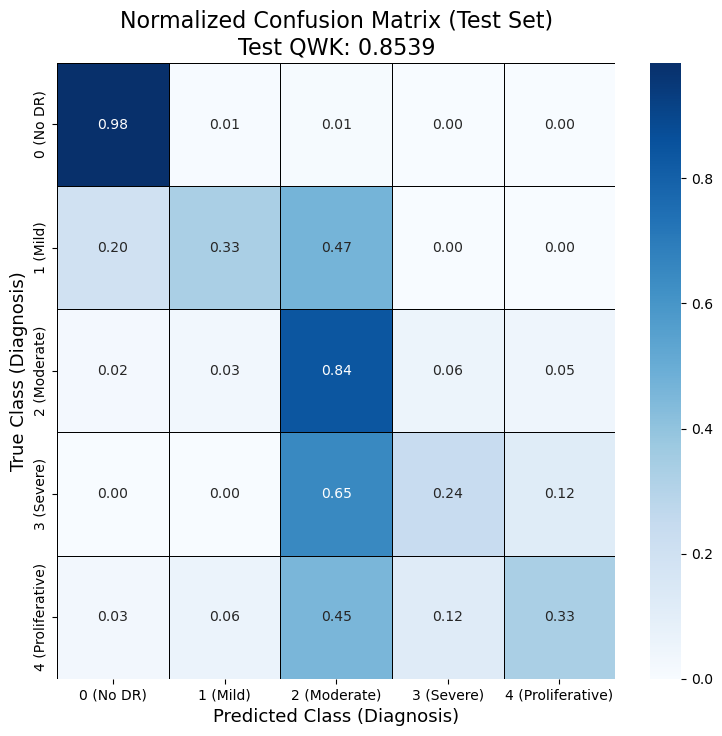

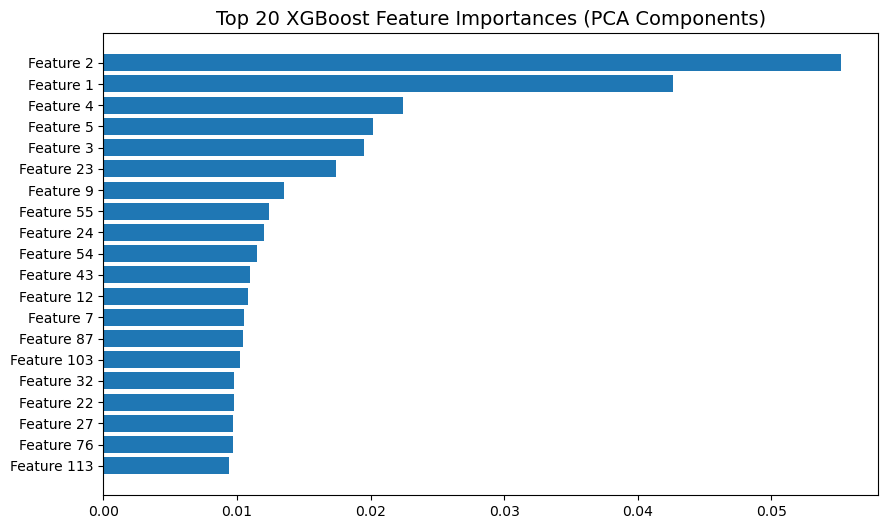

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Final Prediction ---
y_pred_test = xgb_model.predict(X_test_refined)

# --- Final Metrics ---
test_accuracy = accuracy_score(y_test, y_pred_test)
test_qwk = cohen_kappa_score(y_test, y_pred_test, weights='quadratic')

print("\n--- Final Hybrid Model Performance on TEST Set (SMOTE) ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test QWK Score: {test_qwk:.4f}")

# --- Graphics: Normalized Confusion Matrix ---
class_names = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)']
cm = confusion_matrix(y_test, y_pred_test)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, linecolor='black')

plt.title(f'Normalized Confusion Matrix (Test Set)\nTest QWK: {test_qwk:.4f}', fontsize=16)
plt.ylabel('True Class (Diagnosis)', fontsize=13)
plt.xlabel('Predicted Class (Diagnosis)', fontsize=13)
plt.show()

# --- Graphics: Feature Importance ---
plt.figure(figsize=(10, 6))
importances = xgb_model.feature_importances_
top_20_indices = np.argsort(importances)[-20:] 
plt.barh(range(20), importances[top_20_indices], align='center')
plt.yticks(range(20), [f'Feature {i+1}' for i in top_20_indices])
plt.title('Top 20 XGBoost Feature Importances (PCA Components)', fontsize=14)
plt.show()

In [2]:
import joblib
import pickle
import os
# --- File Paths for Saving ---
MODEL_SAVE_DIR = './artifacts'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

PYTORCH_EXTRACTOR_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_extractor.pt')
XGBOOST_CLASSIFIER_PATH = os.path.join(MODEL_SAVE_DIR, 'xgb_classifier.joblib')
PCA_TRANSFORMER_PATH = os.path.join(MODEL_SAVE_DIR, 'pca_transformer.joblib')

# ==============================================================================
# 1. Save the PyTorch Feature Extractor (ResNet50)
# ==============================================================================
# Saving the model's state_dict (weights) is the standard PyTorch practice.
torch.save(extractor.state_dict(), PYTORCH_EXTRACTOR_PATH)
print(f"PyTorch Extractor saved to: {PYTORCH_EXTRACTOR_PATH}")

# ==============================================================================
# 2. Save the XGBoost Classifier
# ==============================================================================
# joblib is recommended for large numpy-heavy objects like XGBoost models.
joblib.dump(xgb_model, XGBOOST_CLASSIFIER_PATH)
print(f"XGBoost Classifier saved to: {XGBOOST_CLASSIFIER_PATH}")

# ==============================================================================
# 3. Save the PCA Transformer
# ==============================================================================
# It is CRITICAL to save the fitted PCA object to ensure new data is
# transformed identically to the training data.
joblib.dump(pca, PCA_TRANSFORMER_PATH)
print(f"PCA Transformer saved to: {PCA_TRANSFORMER_PATH}")

print("\n--- All Hybrid Model Components Saved Successfully ---")

NameError: name 'torch' is not defined